# **Logistic Regression** (2/3/26)
**2802539085 - Dian Rakhmawati Lestari**

Dataset: https://www.kaggle.com/competitions/titanic

In [95]:
# Upload Dataset to Google Colab
from google.colab import files

files.upload()

Saving train.csv to train (2).csv


{'train (2).csv': b'PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked\r\n1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.25,,S\r\n2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C\r\n3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.925,,S\r\n4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1,C123,S\r\n5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.05,,S\r\n6,0,3,"Moran, Mr. James",male,,0,0,330877,8.4583,,Q\r\n7,0,1,"McCarthy, Mr. Timothy J",male,54,0,0,17463,51.8625,E46,S\r\n8,0,3,"Palsson, Master. Gosta Leonard",male,2,3,1,349909,21.075,,S\r\n9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27,0,2,347742,11.1333,,S\r\n10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14,1,0,237736,30.0708,,C\r\n11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4,1,1,PP 9549,16.7,G6,S\r\n12,1,1,"Bonnell, Miss. Elizabeth",female,58,0,0,113783,26.55,C103,

In [96]:
import pandas as pd
train_data = pd.read_csv('/content/train.csv')
print(train_data.shape)

(891, 12)


In [97]:
# show the dataset in training data

train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


banyak kolom yang unecessery

In [98]:
# Drop Unecessary Column

cols_to_drop = ['PassengerId', 'Name', 'Ticket']
train_data = train_data.drop(columns=cols_to_drop)
train_data.shape

(891, 9)

pasasnger hanya sebagai penanda, name kita rasa gabisa diproses model, dan juga tiket sebagai informasi datanya saja, tidak memberikan insight kepada model, sehingga kita drop, awalnya ada 12 fitur-3 sisa 9 variabel.

# **Explaratory Data Analysis (EDA)**

In [99]:
# identify training data structures

train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Cabin     204 non-null    object 
 8   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


seberapa banyak jumlah data, tipe datanya apa aja, ada missing value atau tidak. di sini keliatan

In [100]:
# Summary Statistics for Numerical Columns
train_data.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


mean rata2 brapa, std deviasi brapa, max min, bahasakan dengan baik

gapapa tempel yg kmrn

* **count:** Baris ini menunjukkan berapa banyak data yang tidak kosong di setiap kolom. Terlihat kolom `Age` hanya memiliki 714 data, yang seharusnya memiliki 891 data, ini menunjukkan adanya data yang hilang.

* **mean:** Menunjukkan nilai rata-rata. Sekitar 38% penumpang selamat (nilai 0.38), mayoritas kelas penumpang adalah 2.3 (didominasi kelas menengah ke bawah), dan mayoritas penumpang berusia sekiar 29.7 tahun.

* **std (Standard Deviation):** Menunjukkan seberapa jauh data tersebar dari rata-rata. Kolom `Fare` (harga tiket) memiliki std yang sangat tinggi (49.69), menandakan perbedaan harga tiket antar penumpang yang sangat ekstrem. Nilai standar deviasi yang besar, khususnya pada `Fare`, menunjukkan penyebaran data yang lebar dan kemungkinan adanya **outlier**.

* **min:** Nilai terkecil. Penumpang termuda adalah bayi berusia 0.42 tahun (sekitar 5 bulan). Ada juga tiket seharga 0, menunjukkan beberapa penumpang naik secara gratis.

* **25% (Kuartil 1):** Sebanyak 25% penumpang berusia 20.1 tahun ke bawah, mayoritas di kelas 2 atau 3, dan membayar tiket 7.91 atau kurang. Ini menunjukkan populasi besar penumpang muda dengan tiket murah.

* **50% (Median):** Nilai tengah data. Setengah dari penumpang berusia 28 tahun ke bawah dan berada di kelas 3. Karena median `Survived` adalah 0, ini berarti lebih dari separuh penumpang tidak selamat.

* **75% (Kuartil 3):** Sebanyak 75% penumpang berusia 38 tahun ke bawah dan membayar tiket maksimal 31.00.

* **max:** Nilai tertinggi. Penumpang tertua berusia 80 tahun. Tiket termahal mencapai 512.33, yang merupakan Outlier (nilai ekstrem) karena jauh melampaui rata-rata harga tiket.

In [101]:
# Summary Statistics for Categorical Columns
train_data.describe(include='object')

,Sex,Cabin,Embarked
count,891,204,889
unique,2,147,3
top,male,G6,S
freq,577,4,644


ada beberapa missing value, modusnya apa, dll

In [102]:
# Percentage of Missing Values
# liat missing value di tiap kolomnya

missing_summary = pd.DataFrame({
    'Missing Count': train_data.isnull().sum(),
    'Missing Percentage(%)': (train_data.isnull().mean() * 100).round(2)
})
missing_summary

,Missing Count,Missing Percentage(%)
Survived,0,0.00
Pclass,0,0.00
Sex,0,0.00
Age,177,19.87
SibSp,0,0.00
Parch,0,0.00
Fare,0,0.00
Cabin,687,77.10
Embarked,2,0.22


ada 77% missing value, nah  kita bisa drop dia karena missing valuenya cukup banyak

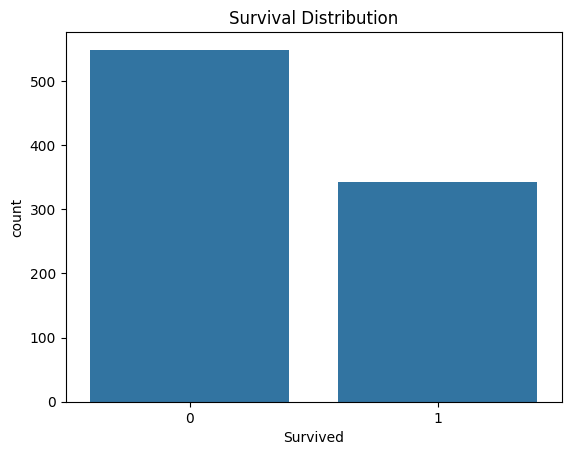

In [103]:
# Bar Chart for Survival Distribution
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Survived', data=train_data)
plt.title('Survival Distribution')
plt.show()

imbalance tidak sama besar, yang tidak selamat banyak

Text(0.5, 1.0, 'Age Distribution')

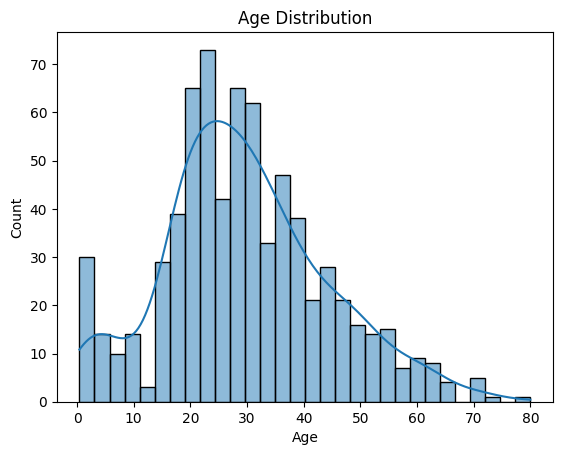

In [104]:
# Histogram for Age Distribution
# positive skew, maka mayoritas passenger berumur sekitar 29.6

sns.histplot(train_data['Age'], bins=30, kde=True)
plt.title('Age Distribution')

age distribution skew, bahasakan interpretasi

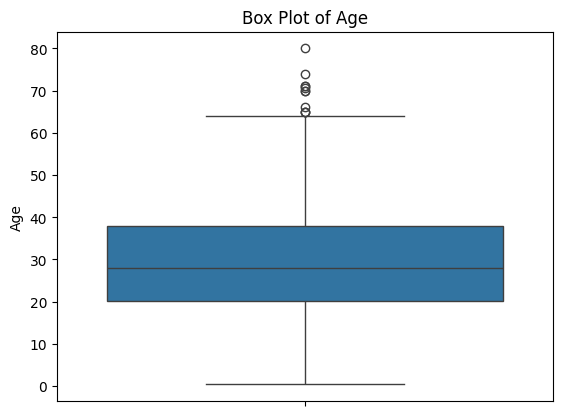

In [105]:
# Box Plot Age

plt.figure()
sns.boxplot(y=train_data['Age'])
plt.title('Box Plot of Age')
plt.show()

terdsapat cukup banyak outlier
di variabel age kita, nilai yang melebihi

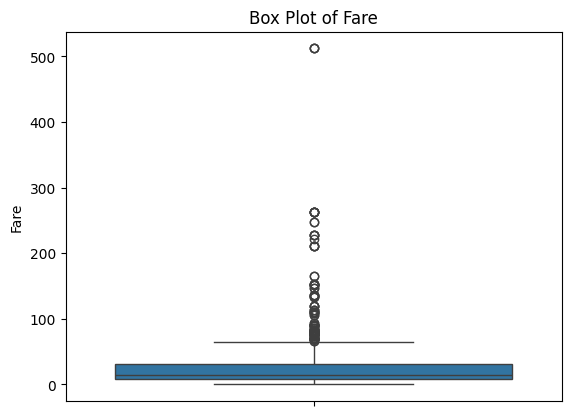

In [106]:
# Box Plot Fare

plt.figure()
sns.boxplot(y=train_data['Fare'])
plt.title('Box Plot of Fare')
plt.show()

outliernya sangat banyak pada fare. jangan langsung di hapus nilai outliernya, takutnya masih memberikan informasi terhadap model yang kita punya. takutnya jika dihapus mengganggu pola dataset yang kita punya

In [107]:
# Correlation-Based Feature Selection

import numpy as np
numerical_cols = train_data.select_dtypes(include=[np.number]).columns
corr = round(train_data[numerical_cols].corr(numeric_only=True), 4)
display(corr)

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.0000,-0.3385,-0.0772,-0.0353,0.0816,0.2573
Pclass,-0.3385,1.0000,-0.3692,0.0831,0.0184,-0.5495
Age,-0.0772,-0.3692,1.0000,-0.3082,-0.1891,0.0961
SibSp,-0.0353,0.0831,-0.3082,1.0000,0.4148,0.1597
Parch,0.0816,0.0184,-0.1891,0.4148,1.0000,0.2162
Fare,0.2573,-0.5495,0.0961,0.1597,0.2162,1.0000


In [108]:
# Creating an Interactive Heatmap

import plotly.express as px
fig = px.imshow(corr,
                text_auto='.2f',
                aspect='auto',
                color_continuous_scale='RdBu_r',
                title='Interactive Correlation Matrix')

fig.update_layout(width=800, height=600)
fig.show()

lebih mudah dibaca dan interactive.
mecoba memilih feature selection menggunakan corelation based feature selection. basically mencari korelasi yang paling kuat antara variabel x dan variabel y, juga mencari korelasi yang paling lemah antara variabel x dan variabel y. itu yang ingin kita lihat
contoh:

kira2 variabel x mana aja sih yang paling memiliki korelasi yang paling kuat dengan variabel y.

contohnya survived, yang cukup besar terlihat pada variabel feature x dengan variabel target y ada Pclass 0.34 dan fare 0.26., ada 2 fitur nih yang memiliki pengaruh antara variabel target si survived ini, nah kita liat korelasi pclass dengan fare cukup besar sekitae -0.54, sehingga yang kita cari itu memiliki variabel y, tetapi sesama variabel x memiliki korelasi cukup tinggi sehingga kita bisa memilih variabel salah satu pclass atau fare, cfs pake itu karena memberikan informasi yang sama (redundan). nnti modelnya ga coba pake itu aja, kita ga pake cfs skrg.

-0.55 maka bisa pilih salah satu antara variable p clas dan fare, karena biasa disebut redundan, nah itu pake corelasi based feature selection

# **Data Pre-Processing**

In [109]:
# Drop Column with 50% > Missing Values

missing_ratio = train_data.isnull().mean()
cols_to_keep = missing_ratio[missing_ratio < 0.5].index
train_data = train_data[cols_to_keep]
train_data.shape

(891, 8)

In [110]:
# Age Imputation menggunakan Mean
# Numerik bisa mean / median
train_data['Age'] = train_data['Age'].fillna(train_data['Age'].mean())

In [111]:
# Embarked filed with Mode(Modus)
train_data['Embarked'] = train_data['Embarked'].fillna(train_data['Embarked'].mode()[0])

In [112]:
# Re-check missing-values

train_data.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


udah aman udah gada missing value

In [113]:
# Preview Dataset
train_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [114]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in['Sex', 'Embarked']:
  train_data[col] = le.fit_transform(train_data['Embarked'])

In [115]:
train_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,2,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,2,26.0,0,0,7.9250,2
3,1,1,2,35.0,1,0,53.1000,2
4,0,3,2,35.0,0,0,8.0500,2


ini bentuknya udah numerik diskrit

In [116]:
# Seperate Target Class

X = train_data.drop(columns=['Survived'], axis=1) #ini X besar
y = train_data['Survived']

variabel survived kita drop, tapi si y nya tetep ada variabel survived

In [117]:
# Split dataset into training and testing 70:30

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

penting untuk menambahkan Stratify, membagi agar kelas survived dan non survived baik itu di data training maupun data testing. kita ingin dia rata balanced, sehingga kita gunakan parameter stratify

In [118]:
# Normalization with Standard Scaler

from sklearn.preprocessing import StandardScaler
scale_cols = ['Age', 'Fare']

scaler = StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

transform dari data training yang sudah kita laukan sebelumnya

In [119]:
# Preview Data

X_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
748,1,2,-0.842505,1,0,0.465738,2
45,3,2,-0.021501,0,0,-0.478269,2
28,3,1,-0.021501,0,0,-0.481848,1
633,1,2,-0.021501,0,0,-0.646954,2
403,3,2,-0.151884,1,0,-0.314823,2


sudah sesuai semua untuk variabel kategorik dengan menggunakan label encoding, untuk numerik juga sudah ditransformasi menggunakan standarscaler sehingga semuanya sudah siap untuk kita lakukan logistic regression

# **Logistic Regression Modelling**

In [120]:
# Train Logistic Regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

jika tabel biru keluar, maka model berhasil melakukan training

In [121]:
# Predict the Testing Data
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

perlu juga mengambil nilai probabilitas untuk mengambil object. mengambil probabilitas nilai positif yang selamat [:1]

In [122]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0])

1 selamat

0 tidak

# **Model Evaluation**

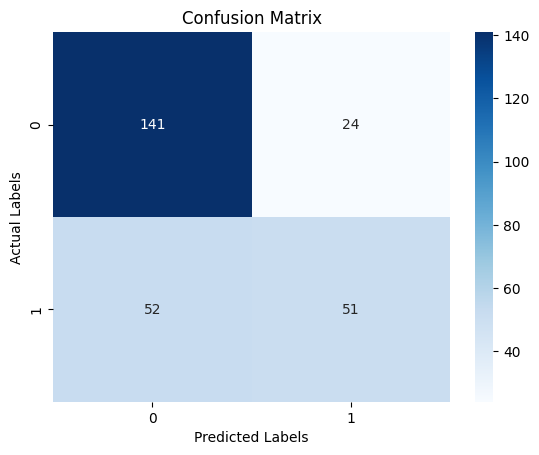

In [123]:
# Confusion Matrix, BENERIN INI HARUSNYA 70 KIRI ATAS
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix')
plt.show()

membandingkan nilai y test yang actual dan y test predict.

ini artinya kiri atas true negative, misalkan contoh true positive. model berhasil memprediksi 73



ini evaluasinya spt apa artinya apa roc curve sama roc harus bagus penjelasannya

In [124]:
#  Matrix Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 score: {f1:.4f}")

Accuracy: 0.7164
Precision: 0.6800
Recall: 0.4951
F1 score: 0.5730


akurasi 79%, dst

nah berikan insight dari angka2 yang ada di sini

akurasi: secara umum model ini sudah cukup baik dapat prediksi 79% dari seluruh data. artinya dari 100 penumpang kira2 79 orang diprediksi dengan tepat

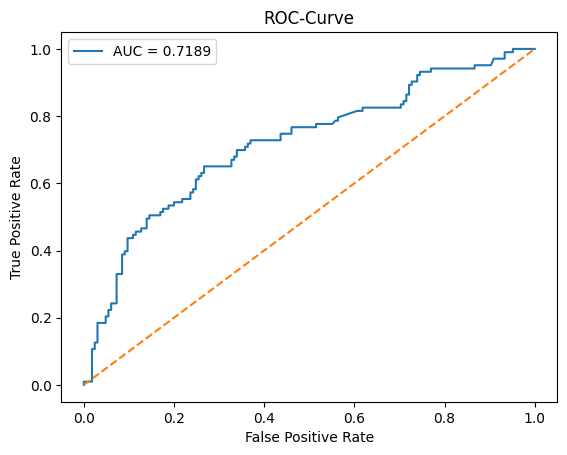

In [125]:
# Create ROC-Curve and AUC

from sklearn.metrics import roc_auc_score, roc_curve

fpr, tpr, tresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-Curve')
plt.legend()
plt.show()

coba otak atik eda, pre process untuk meningkatkan akurasi atau metrix evaluationnya, explore agar meningkatkan performanya, dan juga interpretasi insight yang di dapat, informasi yang didaoat, interpretasikan, dan bisa membahasakan roc curve, grafik gini artinya apa, auc nya 0.5 artinya apa, yang eda copy paste aja di setiap eda yang dilakukan.

itu tugas asssignment minggu ke 4